----------------------------------------
Starting Boids Simulation
  Boids: 100
  World: 1.0x1.0
  Backend: module://matplotlib_inline.backend_inline
----------------------------------------


/tmp/ipython-input-3248164067.py:224: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(


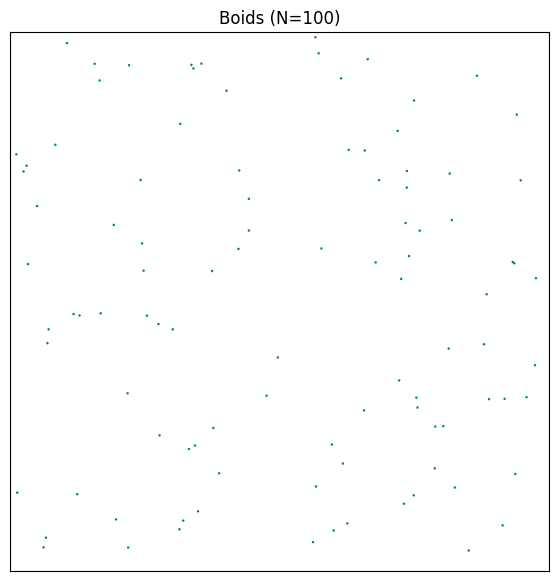

In [8]:
#!/usr/bin/env python3
"""
boids.py

A vectorized 2D Boids (flocking) simulation using NumPy and Matplotlib.
Implements Separation, Alignment, and Cohesion on a Torus (wrap-around) world.

Usage:
    python boids.py
    python boids.py --n-boids 200

Dependencies:
    numpy, matplotlib
"""

import sys
import argparse
import math

# --- 1. Environment & Dependency Check --------------------------------------
try:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation
except ImportError as e:
    print("Error: Missing required dependencies.")
    print(f"Details: {e}")
    print("Please install them via: pip install numpy matplotlib")
    sys.exit(1)

# --- 2. Default Parameters --------------------------------------------------
# World definition
WIDTH = 1.0
HEIGHT = 1.0

# Simulation defaults
N_BOIDS = 100
DT = 0.05  # Time step

# Physics constants
MAX_SPEED = 0.01
MIN_SPEED = 0.003
NEIGHBOR_RADIUS = 0.1   # Perception radius
SEPARATION_RADIUS = 0.03  # Personal space radius

# Rule weights
SEPARATION_WEIGHT = 0.15
ALIGNMENT_WEIGHT = 0.05
COHESION_WEIGHT = 0.01

# --- 3. Core Logic ----------------------------------------------------------

def init_boids(n_boids, width, height):
    """
    Initialize boids with random positions and velocities.

    Args:
        n_boids (int): Number of boids.
        width (float): Width of the world.
        height (float): Height of the world.

    Returns:
        positions (np.ndarray): (N, 2) array of [x, y]
        velocities (np.ndarray): (N, 2) array of [vx, vy]
    """
    positions = np.random.rand(n_boids, 2) * np.array([width, height])

    # Random velocities with magnitude [MIN_SPEED, MAX_SPEED]
    angles = np.random.rand(n_boids) * 2 * np.pi
    speeds = (np.random.rand(n_boids) * (MAX_SPEED - MIN_SPEED)) + MIN_SPEED
    velocities = np.column_stack((np.cos(angles), np.sin(angles))) * speeds[:, None]

    return positions, velocities

def update_boids(positions, velocities, params):
    """
    Perform one update step of the simulation using vectorized operations.

    Args:
        positions (np.ndarray): Current positions (N, 2).
        velocities (np.ndarray): Current velocities (N, 2).
        params (dict): Dictionary of simulation parameters.

    Returns:
        new_positions, new_velocities
    """
    width = params["width"]
    height = params["height"]
    n_boids = positions.shape[0]

    # 1. Calculate pairwise distances on a Torus
    # diff[i, j] is the vector pointing from i to j
    diff = positions[None, :, :] - positions[:, None, :]

    # Wrap differences around boundaries: if diff > width/2, subtract width (shortest path)
    # We perform this element-wise for x (index 0) and y (index 1)
    diff[:, :, 0] = (diff[:, :, 0] + width / 2) % width - width / 2
    diff[:, :, 1] = (diff[:, :, 1] + height / 2) % height - height / 2

    # Squared distances (N, N)
    dist_sq = np.sum(diff**2, axis=2)

    # Ignore self-comparisons (set diagonal to infinity)
    np.fill_diagonal(dist_sq, np.inf)

    # 2. Build Masks
    # Neighbors within visual range
    neighbor_mask = dist_sq < params["neighbor_radius"]**2
    # Neighbors too close (separation)
    separation_mask = dist_sq < params["separation_radius"]**2

    neighbor_counts = np.sum(neighbor_mask, axis=1, keepdims=True)
    # Avoid division by zero
    neighbor_counts[neighbor_counts == 0] = 1

    # 3. Apply Rules

    # Rule 1: Separation
    # Move away from close neighbors. Weight by 1/distance for smoothness.
    # We effectively sum (-diff / dist) for all close neighbors.
    # Add epsilon to dist_sq to prevent div/0.
    sep_vectors = -diff * separation_mask[:, :, None]
    separation = np.sum(sep_vectors / (dist_sq[:, :, None] + 1e-8), axis=1)

    # Rule 2: Alignment
    # Steer towards the average velocity of neighbors.
    avg_vel = np.sum(velocities[None, :, :] * neighbor_mask[:, :, None], axis=1) / neighbor_counts
    alignment = avg_vel - velocities

    # Rule 3: Cohesion
    # Steer towards center of mass of neighbors.
    # Instead of averaging absolute positions (which breaks on Torus), we average relative vectors.
    # avg_rel_pos is the vector from 'self' to the 'center of mass'.
    avg_rel_pos = np.sum(diff * neighbor_mask[:, :, None], axis=1) / neighbor_counts
    cohesion = avg_rel_pos

    # 4. Integrate
    acceleration = (
        separation * params["sep_weight"] +
        alignment * params["align_weight"] +
        cohesion * params["coh_weight"]
    )

    velocities += acceleration * params["dt"]

    # 5. Limit Speed
    speeds = np.linalg.norm(velocities, axis=1, keepdims=True)
    # Clamp speeds to MAX_SPEED (and prevent zero-division)
    speeds = np.maximum(speeds, 1e-8)
    scale_factor = np.where(speeds > params["max_speed"], params["max_speed"] / speeds, 1.0)
    velocities *= scale_factor

    # 6. Update Positions
    positions += velocities * params["dt"]

    # Wrap positions (Torus)
    positions[:, 0] = positions[:, 0] % width
    positions[:, 1] = positions[:, 1] % height

    return positions, velocities

# --- 4. Visualization & Main ------------------------------------------------
def main():
    # CLI Arguments
    parser = argparse.ArgumentParser(description="2D Boids Flocking Simulation")
    parser.add_argument("--n-boids", type=int, default=N_BOIDS,
                        help=f"Number of boids to simulate (default: {N_BOIDS})")
    # When running in a notebook, sys.argv will contain '-f' and the kernel connection file.
    # We pass an empty list to parse_args to prevent it from trying to parse these.
    args = parser.parse_args([])

    n_boids = max(1, args.n_boids)

    # Pack parameters
    params = {
        "width": WIDTH,
        "height": HEIGHT,
        "dt": DT,
        "max_speed": MAX_SPEED,
        "neighbor_radius": NEIGHBOR_RADIUS,
        "separation_radius": SEPARATION_RADIUS,
        "sep_weight": SEPARATION_WEIGHT,
        "align_weight": ALIGNMENT_WEIGHT,
        "coh_weight": COHESION_WEIGHT,
    }

    print("-" * 40)
    print(f"Starting Boids Simulation")
    print(f"  Boids: {n_boids}")
    print(f"  World: {WIDTH}x{HEIGHT}")
    print(f"  Backend: {plt.get_backend()}")
    print("-" * 40)

    # Initialize State
    positions, velocities = init_boids(n_boids, WIDTH, HEIGHT)

    # Setup Plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Boids (N={n_boids})")

    # Initialize Quiver (Arrows)
    # We use a dummy initial array; it will be updated in the animation loop
    quiver = ax.quiver(
        positions[:, 0], positions[:, 1],
        velocities[:, 0], velocities[:, 1],
        angles='xy', scale_units='xy', scale=1/DT,  # scale inverse to DT makes visual speed intuitive
        width=0.005, headwidth=3, headlength=4, color='teal'
    )

    def animate(frame):
        nonlocal positions, velocities
        positions, velocities = update_boids(positions, velocities, params)

        # Update quiver data
        quiver.set_offsets(positions)
        quiver.set_UVC(velocities[:, 0], velocities[:, 1])
        return quiver,

    anim = FuncAnimation(
        fig, animate,
        frames=None, interval=30, blit=True
    )

    try:
        plt.show()
    except KeyboardInterrupt:
        print("\nSimulation stopped by user.")
        sys.exit(0)

if __name__ == "__main__":
    main()